In [1]:
import TNGFunctions as TNG
import PlotFunctions as plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import MATH
import warnings
import os

from scipy.interpolate import interp1d
from astropy.cosmology import WMAP9 as cosmo
from astropy.cosmology import WMAP7
from matplotlib.lines import Line2D


plt.style.use('abhner.mplstyle')
np.seterr(divide='ignore') # ignore divide by zero


warnings.filterwarnings( "ignore")

In [2]:
# cosmological parameters
Omegam0 = 0.3089
h = 0.6774

#SIM TNG
SIMTNG = 'TNG50'

#Paths
dfTime = pd.read_csv(os.getenv("HOME")+'/TNG_Analyzes/SubhaloHistory/SNAPS_TIME.csv')
df_z0_Mstar_Range = pd.read_csv(os.getenv("HOME")+'/TNG_Analyzes/SubhaloHistory/TNG50/DFs/Sample.csv')

# FIG. 1

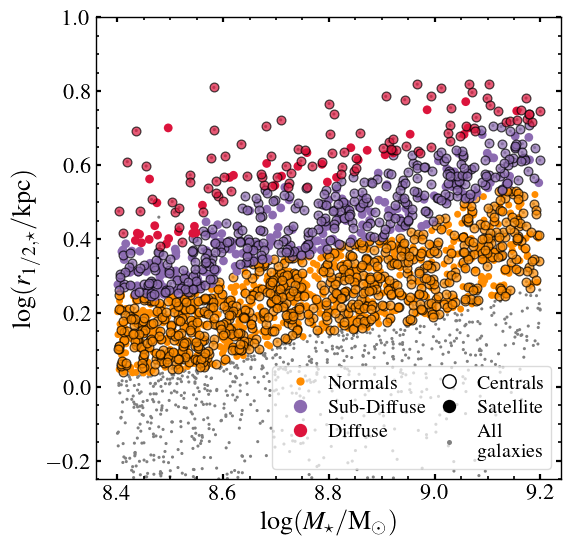

In [3]:
fig=plt.figure(facecolor='white')
plt.rcParams.update({'figure.figsize': (8, 5)})
X = np.transpose(np.array([df_z0_Mstar_Range.logMstarRad_99,df_z0_Mstar_Range.logHalfRadstar_99]))
Masses = np.linspace(8.4, 9.2, 100)


plt.scatter(X[:,0],X[:,1],s=5,c='gray',ec='none')

# Main branch

# Normals

plt.scatter(df_z0_Mstar_Range.logMstarRad_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('NormalSatellite', SubfindID_99 = True))],
            df_z0_Mstar_Range.logHalfRadstar_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('NormalSatellite', SubfindID_99 = True))],
            s=25,c='darkorange', ec= 'none')

plt.scatter(df_z0_Mstar_Range.logMstarRad_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('NormalCentral', SubfindID_99 = True))],
            df_z0_Mstar_Range.logHalfRadstar_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('NormalCentral', SubfindID_99 = True))],
            s=40,c='darkorange', linewidths= 0.9, alpha = 0.7)


# Compact Main branch

plt.scatter(df_z0_Mstar_Range.logMstarRad_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('SubDiffuseSatellite', SubfindID_99 = True))],
            df_z0_Mstar_Range.logHalfRadstar_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('SubDiffuseSatellite', SubfindID_99 = True))],
            s=40,c='#8c6bb1', ec= 'none')

plt.scatter(df_z0_Mstar_Range.logMstarRad_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('SubDiffuseCentral', SubfindID_99 = True))],
            df_z0_Mstar_Range.logHalfRadstar_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('SubDiffuseCentral', SubfindID_99 = True))],
            s=40,c='#8c6bb1', linewidths= .9, alpha = 0.7)



# Compact Secondary branch


plt.scatter(df_z0_Mstar_Range.logMstarRad_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('DiffuseSatellite', SubfindID_99 = True))],
            df_z0_Mstar_Range.logHalfRadstar_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('DiffuseSatellite', SubfindID_99 = True))],
            s=40,c='crimson', ec= 'none')

plt.scatter(df_z0_Mstar_Range.logMstarRad_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('DiffuseCentral', SubfindID_99 = True))],
            df_z0_Mstar_Range.logHalfRadstar_99[df_z0_Mstar_Range.SubfindID_99.isin(TNG.extractPopulation('DiffuseCentral', SubfindID_99 = True))],
            s=40,c='crimson', linewidths= .9, alpha = 0.7)



columnspacing = 0.2
handletextpad = 0.4
labelspacing = 0.3
fontlegend= 24
framealpha= 0.7
alphaScater=0.8
quantile=0.28

custom_lines, label, ncol, mult = plot.Legend(
    ['NormalScatter',  'SubDiffuseScatter', 'DiffuseScatter', 'CentralEmptyBlackLineScatter',  'SatelliteSelectedScatter',  'TNGrageScatter'])
plt.legend(
    custom_lines, label, loc = 'lower right',  ncol=ncol, fontsize=mult*fontlegend, framealpha=framealpha, 
    columnspacing = columnspacing, handletextpad = handletextpad, labelspacing = labelspacing)

plt.ylim(-0.25, 1.0)
#plt.xlim(0, 10)
plt.tick_params(labelsize = 0.85 * 19)
plt.xlabel(r'$\log(M_\star/\mathrm{M}_\odot)$', fontsize = 19)
plt.ylabel(r'$\log(r_{1/2, \star}/\mathrm{kpc})$', fontsize = 19)


plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/' + SIMTNG + '/PaperIII/PlotScatter/masssize.pdf')
plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/' + SIMTNG + '/PaperIII/PlotScatter/masssize.png')

# Fig. 2


 Type:  Central
Normal  X =  0.0103157983747527 Y =  0.0738401367106206
SubDiffuse  X =  0.0092517331737316 Y =  0.0911865945019541
Diffuse  X =  0.00809297195694235 Y =  0.1111813230992464

 Type:  Satellite
Normal  X =  0.0424901741080345 Y =  0.0117031577332215
SubDiffuse  X =  0.030034477564145748 Y =  0.01959679759458775
Diffuse  X =  0.020846843196510152 Y =  0.0365179112069828

 Type:  Central
Normal  X =  0.0103157983747527 Y =  0.9146721257286078
SubDiffuse  X =  0.0092517331737316 Y =  0.8993634754496243
Diffuse  X =  0.00809297195694235 Y =  0.8807944497532076

 Type:  Satellite
Normal  X =  0.0424901741080345 Y =  0.9108987096419472
SubDiffuse  X =  0.030034477564145748 Y =  0.9219262642479739
Diffuse  X =  0.020846843196510152 Y =  0.9273240080698498


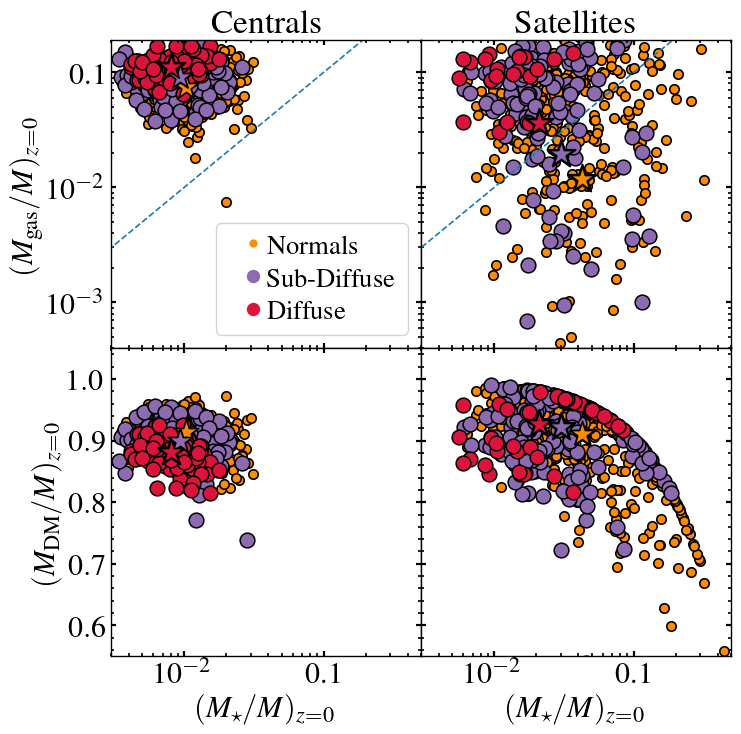

In [4]:
plot.PlotScatter(['Normal', 'SubDiffuse', 'Diffuse'], ['Central', 'Satellite'], 'StarFrac_99', ['GasFrac_99', 'DMFrac_99'],  Type='z0', snap=[99],
                medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalScatter', 'SubDiffuseScatter', 'DiffuseScatter']],  TRANSPARENT = False, COLORBAR = None, medianDot = True, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2,  fontlabel=22, 
                m='o', msizet=14, quantile=0.95,framealpha = 0.85, q = 0.95,
                ylimmin = [0.0004, 0.55], ylimmax = [0.19, 1.05], xlimmin = [0.003, 0.003], xlimmax = [0.1, 0.5], MarkerSizes = None,
                legpositions = [[0,0]],
                loc = ['best'],
                lNum = 4, cNum = 4, msizeMult = 1.5,
                columnspacing = 0.5, handletextpad = -0.5, labelspacing = 0.3,  title= ['Centrals', 'Satellites'],
                savepath='PaperIII/PlotScatter',  savefigname='GasStarFracs', dfName='Sample', SampleName='Samples', cmap = 'inferno',
                bins=10, seed=16010504, mult = 4.1)


# FIG. 3

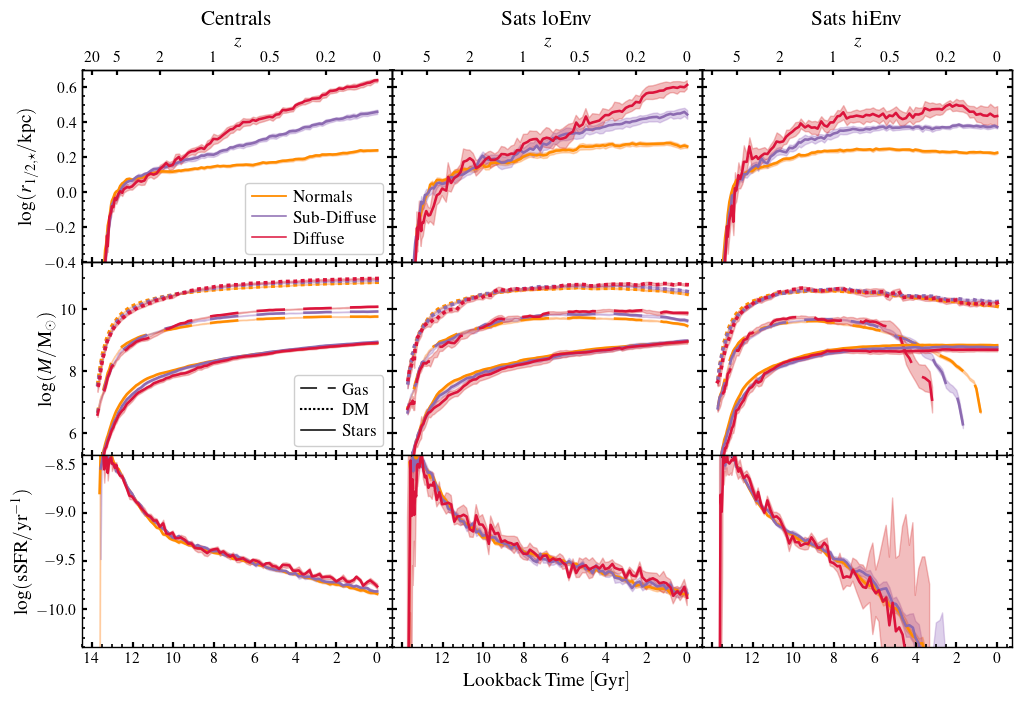

In [5]:
plot.PlotMedianEvolution(['Normal', 'SubDiffuse', 'Diffuse'],['Central', 'SatelliteNotInteract', 'SatelliteInteract'],  
                         [['SubhaloHalfmassRadType4'], 
                          ['SubhaloMassType0', 'SubhaloMassType1', 'SubhaloMassType4'], 
                          ['SubhalosSFR']], 
                    Type='Evolution', Xparam=['Time'], title=['Central', 'SatelliteNotInteract', 'SatelliteInteract'], 
                    savepath='PaperIII/PlotMedianEvolution',  savefigname='AllEvolution', dfName='PaperIII', SampleName='SubfindID_99', 
                    LegendNames=[['Normal', 'SubDiffuse', 'Diffuse'], ['Type0', 'Type1', 'Type4']], 
                    loc = ['best', 'best', 'best'],  loctext = ['best'],
                    ylimmin = [-0.4, 5.3, -10.4], ylimmax = [0.7, 11.5, -8.4], xlimmin = None, xlimmax = None,  
                    legpositions = [[0, 0], [0, 1], [0, 2]],  
                    xlabelintext=False, lineparams= True,  LookBackTime = True, 
                    ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                    Transparent = True, Text = None, Pericenter = False, Supertitle = False,
                    lNum = 2.5, cNum = 4, JustOneXlabel = True,
                    alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,   fontlabel=14,     nboots=100,  multtick = 0.8,
                    Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                    bins=10, seed=16040105)

In [6]:
TNG.compare_Sample_key('rOverR200Mean', [['NormalSatelliteNotInteract', 'SubDiffuseSatelliteNotInteract'],
                               ['NormalSatelliteNotInteract', 'DiffuseSatelliteNotInteract'],
                               ['SubDiffuseSatelliteNotInteract', 'DiffuseSatelliteNotInteract']], dfName = 'PaperIII')
print('\n')

TNG.compare_Sample_key('rOverR200Mean', [['NormalSatelliteInteract', 'SubDiffuseSatelliteInteractr'],
                               ['NormalSatelliteInteract', 'DiffuseSatelliteInteract'],
                               ['SubDiffuseSatelliteInteract', 'DiffuseSatelliteInteract']], dfName = 'PaperIII')
TNG.compare_Sample_key('M200Mean', [['NormalSatelliteNotInteract', 'SubDiffuseSatelliteNotInteract'],
                               ['NormalSatelliteNotInteract', 'DiffuseSatelliteNotInteract'],
                               ['SubDiffuseSatelliteNotInteract', 'DiffuseSatelliteNotInteract']], dfName = 'PaperIII')
print('\n')

TNG.compare_Sample_key('M200Mean', [['NormalSatelliteInteract', 'SubDiffuseSatelliteInteractr'],
                               ['NormalSatelliteInteract', 'DiffuseSatelliteInteract'],
                               ['SubDiffuseSatelliteInteract', 'DiffuseSatelliteInteract']], dfName = 'PaperIII')
TNG.compare_Sample_key('z_At_FirstEntry', [['NormalSatelliteNotInteract', 'SubDiffuseSatelliteNotInteract'],
                               ['NormalSatelliteNotInteract', 'DiffuseSatelliteNotInteract'],
                               ['SubDiffuseSatelliteNotInteract', 'DiffuseSatelliteNotInteract']], dfName = 'PaperIII')
print('\n')

TNG.compare_Sample_key('z_At_FirstEntry', [['NormalSatelliteInteract', 'SubDiffuseSatelliteInteractr'],
                               ['NormalSatelliteInteract', 'DiffuseSatelliteInteract'],
                               ['SubDiffuseSatelliteInteract', 'DiffuseSatelliteInteract']], dfName = 'PaperIII')

NormalSatelliteNotInteract  and  SubDiffuseSatelliteNotInteract
Medians:  0.719 0.709
Observed Test Statistic: 0.01079
Permutation Test P-Value: 0.83642
NormalSatelliteNotInteract  and  DiffuseSatelliteNotInteract
Medians:  0.719 0.768
Observed Test Statistic: 0.04878
Permutation Test P-Value: 0.54512
SubDiffuseSatelliteNotInteract  and  DiffuseSatelliteNotInteract
Medians:  0.709 0.768
Observed Test Statistic: 0.05957
Permutation Test P-Value: 0.3329


NormalSatelliteInteract  and  SubDiffuseSatelliteInteractr
Medians:  0.796 0.908
Observed Test Statistic: 0.11195
Permutation Test P-Value: 0.00738
NormalSatelliteInteract  and  DiffuseSatelliteInteract
Medians:  0.796 0.803
Observed Test Statistic: 0.00717
Permutation Test P-Value: 1.0
SubDiffuseSatelliteInteract  and  DiffuseSatelliteInteract
Medians:  0.908 0.803
Observed Test Statistic: 0.10479
Permutation Test P-Value: 0.278
NormalSatelliteNotInteract  and  SubDiffuseSatelliteNotInteract
Medians:  11.948 11.951
Observed Test Statis

# FIG. 4

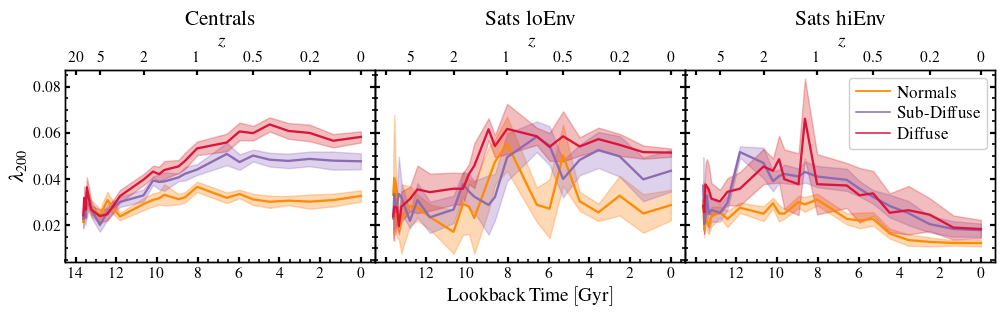

In [7]:
plot.PlotMedianEvolution(['Normal', 'SubDiffuse', 'Diffuse'],['Central', 'SatelliteNotInteract', 'SatelliteInteract'],  
                         ['l200'], 
                    Type='Evolution', Xparam=['Time'], title=['Central', 'SatelliteNotInteract', 'SatelliteInteract'], 
                    savepath='PaperIII/PlotMedianEvolution',  savefigname='AngularEvoluton', dfName='PaperIII', SampleName='SubfindID_99', 
                    LegendNames=[['Normal', 'SubDiffuse', 'Diffuse']], 
                    loc = ['best'],  loctext = ['best'],
                    #ylimmin = [-0.4, 5.3, -10.1], ylimmax = [0.7, 11.5, -7.8], xlimmin = None, xlimmax = None,  
                    legpositions = [[2, 0]],  XScaleSymlog = False,
                    xlabelintext=False, lineparams= False,  LookBackTime = True, 
                    ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                    Transparent = True, Text = None, Pericenter = False, Supertitle = False,
                    lNum = 2.5, cNum = 4, JustOneXlabel = True,
                    alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,   fontlabel=14,     nboots=100,  multtick = 0.8,
                    Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                    bins=10, seed=16040105)

In [8]:
TNG.compare_Sample_key('Median_AllMergers', [['NormalCentralMoreOneMajorMerger', 'SubDiffuseCentralMoreOneMajorMerger'],
                               ['NormalCentralMoreOneMajorMerger', 'DiffuseCentralMoreOneMajorMerger'],
                               ['SubDiffuseCentralMoreOneMajorMerger', 'DiffuseCentralMoreOneMajorMerger']], dfName = 'PaperIII')
print('\n')

TNG.compare_Sample_key('Median_AllMergers', [['NormalSatelliteNotInteractMoreOneMajorMerger', 'SubDiffuseSatelliteNotInteractMoreOneMajorMerger'],
                               ['NormalSatelliteNotInteractMoreOneMajorMerger', 'DiffuseSatelliteNotInteractMoreOneMajorMerger'],
                               ['SubDiffuseSatelliteNotInteractMoreOneMajorMerger', 'DiffuseSatelliteNotInteractMoreOneMajorMerger']], dfName = 'PaperIII')
print('\n')

TNG.compare_Sample_key('Median_AllMergers', [['NormalSatelliteInteractMoreOneMajorMerger', 'SubDiffuseSatelliteInteractMoreOneMajorMerger'],
                               ['NormalSatelliteInteractMoreOneMajorMergerr', 'DiffuseSatelliteInteractMoreOneMajorMerger'],
                               ['SubDiffuseSatelliteInteractMoreOneMajorMerger', 'DiffuseSatelliteInteractMoreOneMajorMerger']], dfName = 'PaperIII')           ['SubDiffuseSatelliteInteractFalse', 'DiffuseSatelliteInteractFalse']], dfName = 'PaperIII')
print('\n')

SyntaxError: unmatched ']' (1901005927.py, line 13)

In [ ]:
TNG.compare_Sample_key('Median_AllMergers', [['NormalCentralNoneMajorMerger', 'SubDiffuseCentralNoneMajorMerger'],
                               ['NormalCentralNoneMajorMerger', 'DiffuseCentralFalse'],
                               ['SubDiffuseCentralNoneMajorMerger', 'DiffuseCentralNoneMajorMerger']], dfName = 'PaperIII')
print('\n')

TNG.compare_Sample_key('Median_AllMergers', [['NormalSatelliteNotInteractNoneMajorMerger', 'SubDiffuseSatelliteNotInteractNoneMajorMerger'],
                               ['NormalSatelliteNotInteractNoneMajorMerger', 'DiffuseSatelliteNotInteractNoneMajorMerger'],
                               ['SubDiffuseSatelliteNotInteractNoneMajorMerger', 'DiffuseSatelliteNotInteractNoneMajorMerger']], dfName = 'PaperIII')
print('\n')

TNG.compare_Sample_key('Median_AllMergers', [['NormalSatelliteInteractNoneMajorMerger', 'SubDiffuseSatelliteInteractNoneMajorMerger'],
                               ['NormalSatelliteInteractNoneMajorMerger', 'DiffuseSatelliteInteractNoneMajorMerger'],
                               ['SubDiffuseSatelliteInteractNoneMajorMerger', 'DiffuseSatelliteInteractNoneMajorMerger']], dfName = 'PaperIII')
print('\n')

NormalCentralNoneMajorMerger  and  SubDiffuseCentralNoneMajorMerger
Medians:  nan nan
Observed Test Statistic: nan
Permutation Test P-Value: 0.0
NormalCentralNoneMajorMerger  and  DiffuseCentralFalse
Medians:  nan 10.021
Observed Test Statistic: nan
Permutation Test P-Value: 0.0
SubDiffuseCentralNoneMajorMerger  and  DiffuseCentralNoneMajorMerger
Medians:  nan nan
Observed Test Statistic: nan
Permutation Test P-Value: 0.0


NormalSatelliteNotInteractNoneMajorMerger  and  SubDiffuseSatelliteNotInteractNoneMajorMerger
Medians:  nan nan
Observed Test Statistic: nan
Permutation Test P-Value: 0.0
NormalSatelliteNotInteractNoneMajorMerger  and  DiffuseSatelliteNotInteractNoneMajorMerger
Medians:  nan nan
Observed Test Statistic: nan
Permutation Test P-Value: 0.0
SubDiffuseSatelliteNotInteractNoneMajorMerger  and  DiffuseSatelliteNotInteractNoneMajorMerger
Medians:  nan nan
Observed Test Statistic: nan
Permutation Test P-Value: 0.0


NormalSatelliteInteractNoneMajorMerger  and  SubDiffuseSate

# FIG. 5


 Type:  Central
Name:  Central
X and Y
Spearman rank correlation coefficient: 0.040
P-value: 5.26e-01
X and ColorBAR
Spearman rank correlation coefficient: 0.537
P-value: 1.48e-20
Y and ColorBAR
Spearman rank correlation coefficient: 0.088
P-value: 1.58e-01

 Type:  SatelliteNotInteract
Name:  SatelliteNotInteract
X and Y
Spearman rank correlation coefficient: 0.390
P-value: 7.35e-03
X and ColorBAR
Spearman rank correlation coefficient: 0.362
P-value: 1.33e-02
Y and ColorBAR
Spearman rank correlation coefficient: -0.113
P-value: 4.54e-01

 Type:  SatelliteInteract
Name:  SatelliteInteract
X and Y
Spearman rank correlation coefficient: 0.058
P-value: 5.57e-01
X and ColorBAR
Spearman rank correlation coefficient: 0.307
P-value: 1.42e-03
Y and ColorBAR
Spearman rank correlation coefficient: 0.122
P-value: 2.13e-01

 Type:  Central
Name:  Central
X and Y
Spearman rank correlation coefficient: 0.230
P-value: 2.03e-04
X and ColorBAR
Spearman rank correlation coefficient: 0.561
P-value: 1.20

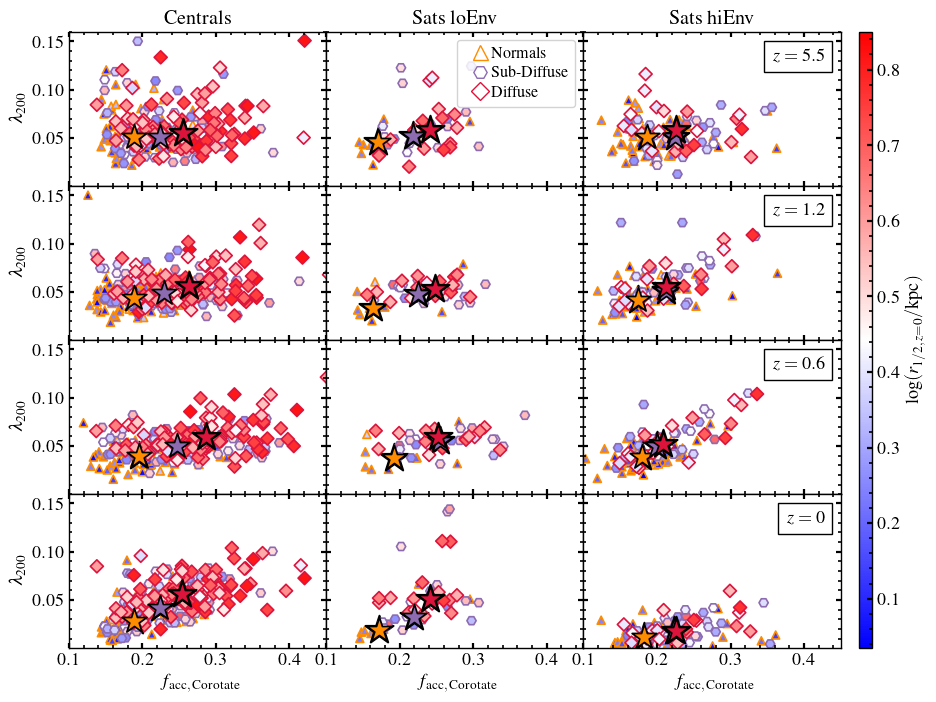

In [9]:
plot.PlotScatter(['Normal', 'SubDiffuse', 'Diffuse'],['Central', 'SatelliteNotInteract', 'SatelliteInteract'], ['CumulativeCorotateFraction_at_1', 'CumulativeCorotateFraction_at_5', 'CumulativeCorotateFraction_at_8', 'CumulativeCorotateFraction'], ['l200_NewMeanAfter1Gyr', 'l200_NewMeanAfter5Gyr', 'l200_NewMeanAfter8Gyr', 'l200_New_at_99'],  Type='z0', snap=[99],
 title=['Central', 'SatelliteNotInteract', 'SatelliteInteract'], medianBins=False, medianAll=False, xlabelintext=True, All=None,
                legend=True, LegendNames=[['NormalColorbarEmptyScatter', 'SubDiffuseColorbarEmptyScatter', 'DiffuseColorbarEmptyScatter']],  TRANSPARENT = False, COLORBAR = ['logHalfRadstar_99', 'logHalfRadstar_99', 'logHalfRadstar_99', 'logHalfRadstar_99'], medianDot = True, SpearManTestAll = True,
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=13.2,  
                m='o', msizet=5.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 2, cNum = 4, GridMake = False,
                ylimmin = [0.0005, 0.0005, 0.0005,0.0005], ylimmax = [0.16, 0.16, 0.16, 0.16], xlimmin = [0.1, 0.1, 0.1, 0.1], xlimmax = [0.45, 0.45, 0.45, 0.45],  
                legpositions = [[1, 0]],  
                columnspacing = 0.5, handletextpad = -0.3, labelspacing = 0.3, loc = ['best'],
                savepath='PaperIII/PlotScatter',  savefigname='l200_frac', dfName='PaperIII', SampleName='Samples', cmap = 'bwr',
                bins=10, seed=16010504, mult = 3.1)

# Fig. 6

Normal: 5.802623263270975
SubDiffuse: 6.6270367044253815
Diffuse: 6.493534789316629
Normal: 5.616312839033608
SubDiffuse: 5.616312839033608
Diffuse: 5.521230066111288
Normal: 5.583806694106901
SubDiffuse: 5.530882643708981
Diffuse: 5.674092624547469


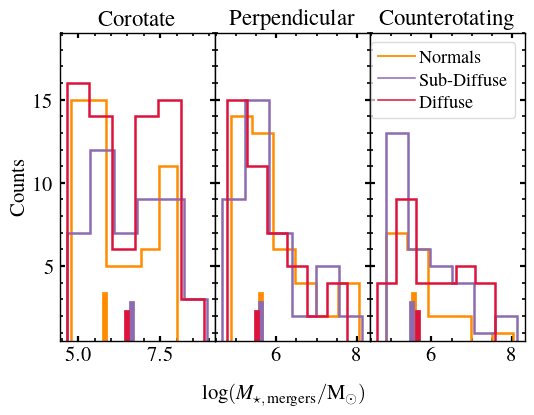

In [10]:
plot.PlotHist(['Normal', 'SubDiffuse', 'Diffuse'], ['logSUM_Mstar_merger_Corotate',
             'logSUM_Mstar_merger_Perpendicular', 'logSUM_Mstar_merger_Counterotating'], [''],
                 Type = 'z0',
               savepath='PaperIII/PlotHist',  savefigname='Mergers', dfName='PaperIII', SampleName='SubfindID_99', 
                density=False, JustOneXlabel = True,
                ColumnPlot = False, bins=6, median=True,  legend = True, 
                lNum = 4, cNum = 2,
                LegendNames = [[ 'Normal', 'SubDiffuse', 'Diffuse']], 
                loc = ['upper right'],
                legpositions= [[2,0]],
                title = ['Corotate',
                             'Perpendicular', 'Counterotating'],
               TRANSPARENT = True, LookBackTime = True,
                fontlabel=15, toplim = 19,
                framealpha=0.7, handletextpad = 0.25)

In [ ]:
TNG.compare_Sample_key('logSUM_Mstar_merger_Corotate', [['Normal', 'SubDiffuse'],
                                             ['Normal', 'Diffuse'],
                                             ['SubDiffuse', 'Diffuse']], dfName = 'PaperIII')

Normal  and  SubDiffuse
Medians:  5.803 6.627
Observed Test Statistic: 0.82441
Permutation Test P-Value: 0.0293
Normal  and  Diffuse
Medians:  5.803 6.494
Observed Test Statistic: 0.69091
Permutation Test P-Value: 0.09908
SubDiffuse  and  Diffuse
Medians:  6.627 6.494
Observed Test Statistic: 0.1335
Permutation Test P-Value: 0.80114


# Fig. 7


 Type:  Central
Name:  Central
X and Y
Spearman rank correlation coefficient: -0.033
P-value: 5.97e-01
X and ColorBAR
Spearman rank correlation coefficient: -0.023
P-value: 7.20e-01
Y and ColorBAR
Spearman rank correlation coefficient: 0.608
P-value: 3.06e-27

 Type:  SatelliteNotInteract
Name:  SatelliteNotInteract
X and Y
Spearman rank correlation coefficient: -0.195
P-value: 1.88e-01
X and ColorBAR
Spearman rank correlation coefficient: -0.179
P-value: 2.28e-01
Y and ColorBAR
Spearman rank correlation coefficient: 0.647
P-value: 9.10e-07

 Type:  SatelliteInteract
Name:  SatelliteInteract
X and Y
Spearman rank correlation coefficient: 0.267
P-value: 7.44e-03
X and ColorBAR
Spearman rank correlation coefficient: 0.019
P-value: 8.54e-01
Y and ColorBAR
Spearman rank correlation coefficient: 0.185
P-value: 6.66e-02


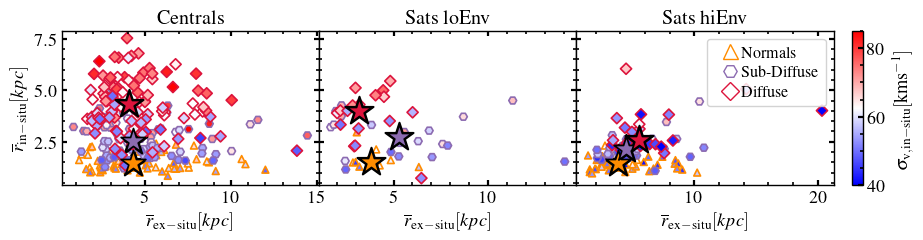

In [16]:
plot.PlotScatter(['Normal', 'SubDiffuse', 'Diffuse'],['Central', 'SatelliteNotInteract', 'SatelliteInteract'], 'RadEx', ['RadIn'],  Type='z0', snap=[99],
 title=['Central', 'SatelliteNotInteract', 'SatelliteInteract'], medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalColorbarEmptyScatter', 'SubDiffuseColorbarEmptyScatter', 'DiffuseColorbarEmptyScatter']],  TRANSPARENT = False, 
                COLORBAR = ['SigmaIn'], medianDot = True, SpearManTestAll = True,
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=13.2,  
                m='o', msizet=6.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 2, cNum = 4, GridMake = False,
                #ylimmin = [0.0005, 0.0005, 0.0005,0.0005], ylimmax = [0.16, 0.16, 0.16, 0.16], xlimmin = [0.1, 0.1, 0.1, 0.1], xlimmax = [0.45, 0.45, 0.45, 0.45],  
                legpositions = [[2, 0]],  ratioColorbar = 15,
                columnspacing = 0.5, handletextpad = -0.3, labelspacing = 0.3, loc = ['best'],
                savepath='PaperIII/PlotScatter',  savefigname='ExIn', dfName='PaperIII', SampleName='Samples', cmap = 'bwr',
                bins=10, seed=16010504, mult = 4.1)


 Type:  Central
Name:  Central
X and Y
Spearman rank correlation coefficient: -0.012
P-value: 6.95e-01

 Type:  SatelliteNotInteract
Name:  SatelliteNotInteract
X and Y
Spearman rank correlation coefficient: 0.156
P-value: 1.03e-02

 Type:  SatelliteInteract
Name:  SatelliteInteract
X and Y
Spearman rank correlation coefficient: -0.096
P-value: 2.25e-02


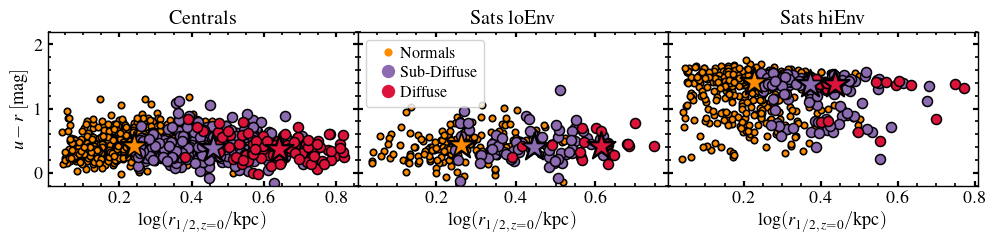

In [ ]:
plot.PlotScatter(['Normal', 'SubDiffuse', 'Diffuse'],['Central', 'SatelliteNotInteract', 'SatelliteInteract'], 'logHalfRadstar_99', ['U-r'],  Type='z0', snap=[99],
 title=['Central', 'SatelliteNotInteract', 'SatelliteInteract'], medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalScatter', 'SubDiffuseScatter', 'DiffuseScatter']],  TRANSPARENT = False, 
                medianDot = True, SpearManTestAll = True,
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=13.2,  
                m='o', msizet=6.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 2, cNum = 4, GridMake = False, ratioColorbar = 15,
                ylimmin = [-0.2], ylimmax = [2.2], 
                legpositions = [[1, 0]],   
                columnspacing = 0.5, handletextpad = -0.3, labelspacing = 0.3, loc = ['upper left'],
                savepath='PaperIII/PlotScatter',  savefigname='Color', dfName='PaperIII', SampleName='Samples', cmap = 'bwr',
                bins=10, seed=16010504, mult = 4.1)